Di seguito si riportano i plot portando p in (1-p), curiosamente l'andamento sembra rispettare le aspettative teoriche.

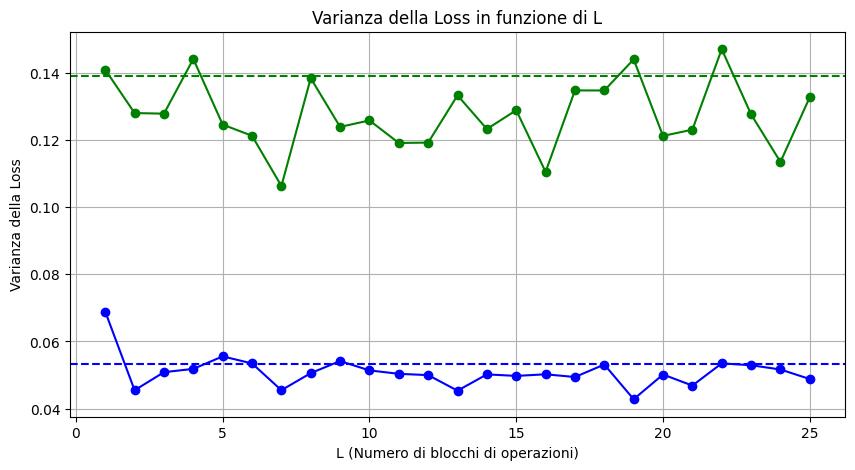

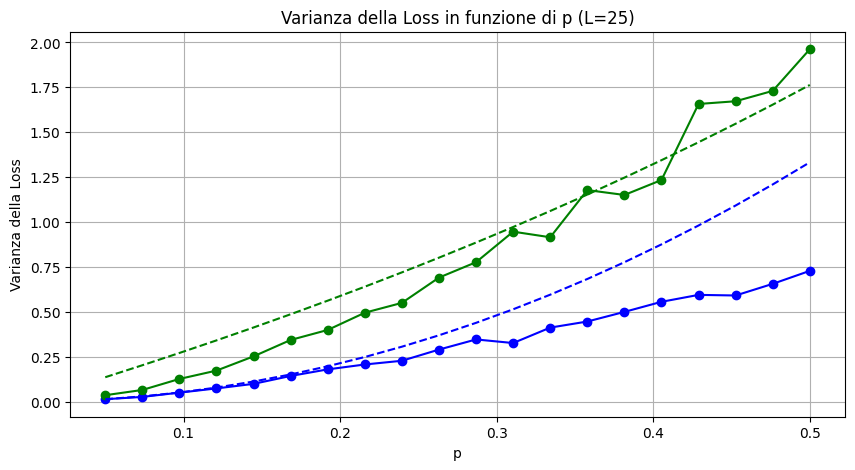

In [16]:
from inspect import trace
import numpy as np
import itertools
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.sparse.csgraph import connected_components
import qiskit as qc
from qiskit_aer import Aer
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, SparsePauliOp, Operator


# Parametri
n=4
shots = 500 # Numero di esecuzioni
L_values_range = 25  # Numero massimo di blocchi di operazioni
p = 0.1  # Probabilità di applicare lo stato GHZ
h = 1  # Coefficiente nell'Hamiltoniano

# Funzione per generare parametri casuali
def generate_random_parameters(n):
    return 2 * np.pi * np.random.rand(2 * n)

# Funzione per mescolare rho con lo stato GHZ

def rho_noise(p, rho):
    rho_ghz = np.zeros_like(rho)
    rho_ghz[0, 0] = 0.5
    rho_ghz[-1, -1] = 0.5
    rho_ghz[0, -1] = 0.5
    rho_ghz[-1, 0] = 0.5
    return (p)* rho + (1-p) * rho_ghz

# Funzione per costruire il circuito e applicare il rumore
def circuit_with_noise(n, p, L):
    circuit = QuantumCircuit(n)
    rho = DensityMatrix.from_instruction(circuit).data  # Matrice densità iniziale
    # Applica rotazioni casuali
    parameters = generate_random_parameters(n)
    for i in range(n):
      circuit.rx(parameters[2 * i], i)
      circuit.rz(parameters[2 * i + 1], i)
    circuit.cx(0,1)
    for i in range (n-2):
      circuit.cx(i+1, i+2)
      circuit.cx(i, i+1)
    circuit.cx(n-2,n-1)

    W=np.array(qc.quantum_info.Operator(circuit))
    for _ in range(L):
      # Evoluzione dello stato
      rho = W @ rho @ W.conj().T
      rho = rho_noise(p, rho)
    return rho

def circuit_with_noise_slow(n, p, L):
    circuit = QuantumCircuit(n)
    rho1 = DensityMatrix.from_instruction(circuit).data

    for i in range(n-1):
      parameters = generate_random_parameters(n)
      circuit.rx(parameters[2 * i], i)
      circuit.rz(parameters[2 * i + 1], i)
    # Applica i CNOT e gli swap
    circuit.crx(np.pi / 20, 0, 1)
    circuit.crx(np.pi / 20, 1, 2)
    circuit.crx(np.pi / 20, 2, 3)

    W=np.array(qc.quantum_info.Operator(circuit))
    for _ in range(L):# Evoluzione dello stato
        rho1 = W @ rho1 @ W.conj().T
        rho1 = rho_noise(p, rho1)
    return rho1

# Creazione dell'Hamiltoniano W
pauli_strings = []
coefficients = []

for k in range(n-1):
     # Coefficiente del termine
    coefficients.append(h *(2**(n/2)))
    # Stringa di Pauli per Z_k ⊗ Z_{k+1}
    pauli_string = ['I'] * n
    pauli_string[k] = 'Z'  # Z_k
    pauli_string[(k + 1)] = 'Z'  # Z_{k+1} (periodico)
    pauli_strings.append("".join(pauli_string))

# Creazione dell'Hamiltoniano come SparsePauliOp
W = SparsePauliOp(pauli_strings, coeffs=np.array(coefficients))

# Lista per memorizzare i valori di L
L_values_all = {L: [] for L in range(1, L_values_range + 1)}
L_values_all1 = {L: [] for L in range(1, L_values_range + 1)}

for L in range(1, L_values_range + 1):
    L_values_shots = []
    L_values_shots1 = []

    for _ in range(shots):
        rho = circuit_with_noise(n, p, L)  # Stato con rumore
        W_matrix = W.to_matrix()
        L_value = np.trace(W_matrix @ rho.data)  # Loss
        L_values_shots.append(L_value)

        rho1 = circuit_with_noise_slow(n, p, L)  # Stato con rumore
        W_matrix = W.to_matrix()
        L_value1 = np.trace(W_matrix @ rho1.data)  # Loss
        L_values_shots1.append(L_value1)

    L_values_all[L] = L_values_shots
    L_values_all1[L] = L_values_shots1

L_means = {L: np.mean(L_values_all[L]) for L in range(1, L_values_range + 1)}
L_variances = {L: np.var(L_values_all[L]) for L in range(1, L_values_range + 1)}
L_means1 = {L: np.mean(L_values_all1[L]) for L in range(1, L_values_range + 1)}
L_variances1 = {L: np.var(L_values_all1[L]) for L in range(1, L_values_range + 1)}

# Plot della varianza in funzione di L
L_range = list(L_variances.keys())
var_values = list(L_variances.values())
L_values = list(L_means.values())
var_values1 = list(L_variances1.values())
L_values1 = list(L_means1.values())
var_values1 = np.array(var_values1, dtype=float)


plt.figure(figsize=(10, 5))
plt.plot(L_range, var_values, marker='o', linestyle='-', color='b')
plt.plot(L_range, var_values1, marker='o', linestyle='-', color='g')
plt.xlabel('L (Numero di blocchi di operazioni)')
plt.ylabel('Varianza della Loss')
plt.title('Varianza della Loss in funzione di L')
plt.axhline( 5.33*p**2, linestyle='--', color='b')
plt.axhline( (p/(2-p))*5.29/2 , linestyle='--', color='g')
plt.grid(True)
plt.show()

p_values = np.linspace(0.05, 0.5, 20)

for p in p_values:
    L_values_shots = []
    L_values_shots1 = []
    for _ in range(shots):
        rho = circuit_with_noise(n, p, L_values_range)
        rho1=circuit_with_noise_slow(n,p, L_values_range)  # Stato con rumore
        W_matrix = W.to_matrix()
        L_value = np.trace(W_matrix @ rho.data)
        L_value1 = np.trace(W_matrix @ rho1.data)  # Loss
        L_values_shots.append(L_value)
        L_values_shots1.append(L_value1)
    L_values_all[p] = L_values_shots
    L_values_all1[p] = L_values_shots1

L_means = {p: np.mean(L_values_all[p]) for p in p_values}
L_variances = {p: np.var(L_values_all[p]) for p in p_values}
L_means1 = {p: np.mean(L_values_all1[p]) for p in p_values}
L_variances1 = {p: np.var(L_values_all1[p]) for p in p_values}

var_values = list(L_variances.values())
L_values = list(L_means.values())
var_values1 = list(L_variances1.values())
L_values1 = list(L_means1.values())
var_values1 = np.array(var_values1, dtype=float)

# Plot della varianza in funzione di p
plt.figure(figsize=(10, 5))
plt.plot(p_values, var_values, marker='o', linestyle='-', color='b')
plt.plot(p_values, var_values1, marker='o', linestyle='-', color='g')
plt.xlabel('p')
plt.ylabel('Varianza della Loss')
plt.title(f'Varianza della Loss in funzione di p (L={L_values_range})')
y=5.33*p_values**2
plt.plot(p_values, y, color='b', linestyle='--', label="Linea orizzontale")
y= (p_values/(2-p_values))*5.29
plt.plot( p_values, y, color='g', linestyle='--', label="Linea orizzontale")
plt.grid(True)
plt.show()